In [1]:
import pandas as pd 
listings_clean = pd.read_csv('../data/listings_clean.csv')

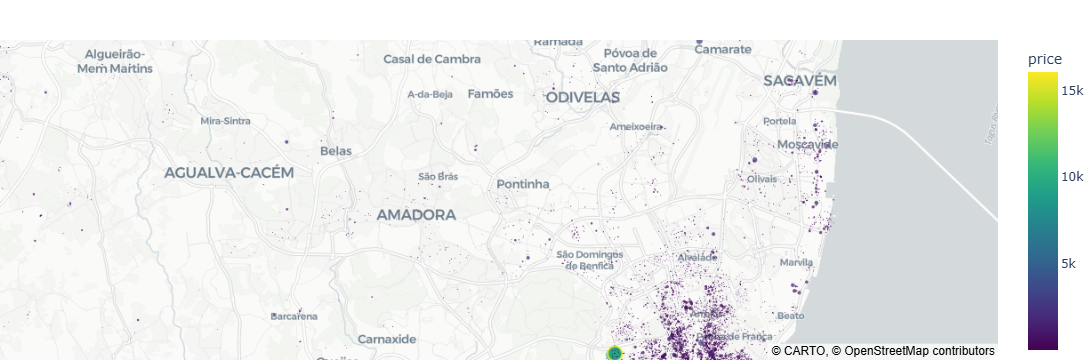

In [3]:
import plotly.express as px

# 1. Quick sanity check: Drop rows where critical map columns are missing
df_map = listings_clean.dropna(subset=['latitude', 'longitude', 'price']).copy()

# 2. Safely cast price to a numeric format just in case it's stored as a string
import pandas as pd
df_map['price'] = pd.to_numeric(df_map['price'], errors='coerce')
df_map = df_map.dropna(subset=['price'])

fig = px.scatter_map(
    df_map,
    lat='latitude',
    lon='longitude',
    color='price',                
    size='price',                 # Link size to price
    size_max=12,                  
    color_continuous_scale='Viridis',
    hover_name='name' if 'name' in df_map.columns else None, # Fallback if 'name' doesn't exist
    zoom=11,
    map_style='carto-positron'    
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()


# ==============================================================================
# INTERACTIVE MAP ENHANCEMENTS SUMMARY:
# 1. Upgraded to 'px.scatter_map' & 'map_style' to match Plotly 6.x standards.
# 2. Implemented data cleaning to drop missing (NaN) coordinates and ensure numeric prices.
# 3. Added dynamic point sizing based on listing price to visually highlight expensive areas.
# 4. Formatted hover tooltips to show clean, localized currency values while hiding raw lat/lon.
# 5. Maximized map workspace by removing default white margins.
# ==============================================================================


In [14]:

import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format

neighborhood_stats = (
    listings_clean
    .groupby('neighbourhood_cleansed')
    .agg(
        median_price=('price', 'median'),
        n_listings=('id', 'count'),
        avg_rating=('review_scores_rating', 'mean')
    )
    # 1. Filter out low-volume neighborhoods to avoid skewed ratings/prices
    .query('n_listings >= 5') 
    
    # 2. Sort by price, then by rating as a secondary metric
    .sort_values(by=['median_price', 'avg_rating'], ascending=[False, False])
)

neighborhood_stats.to_csv('../data/neighborhood_stats.csv', index=False)

# 3. Add styling to the final printout to see patterns instantly
neighborhood_stats.head(15).style.background_gradient(
    cmap='Blues', 
    subset=['median_price', 'n_listings']
).format({
    'median_price': '${:,.2f}',
    'avg_rating': '{:.2f}/5'
})


,median_price,n_listings,avg_rating
neighbourhood_cleansed,,,
Azambuja,$280.66,10,3.93/5
Santa Brbara,$250.00,35,4.89/5
Aldeia Galega da Merceana e Aldeia Gavinha,$238.00,7,4.87/5
Bucelas,$232.33,9,4.76/5
Dois Portos e Runa,$225.00,18,4.97/5
Cadaval e Pro Moniz,$219.54,18,4.86/5
Ribamar,$214.75,46,4.78/5
Abrigada e Cabanas de Torres,$206.00,12,5.00/5
Colares,$205.33,487,4.77/5


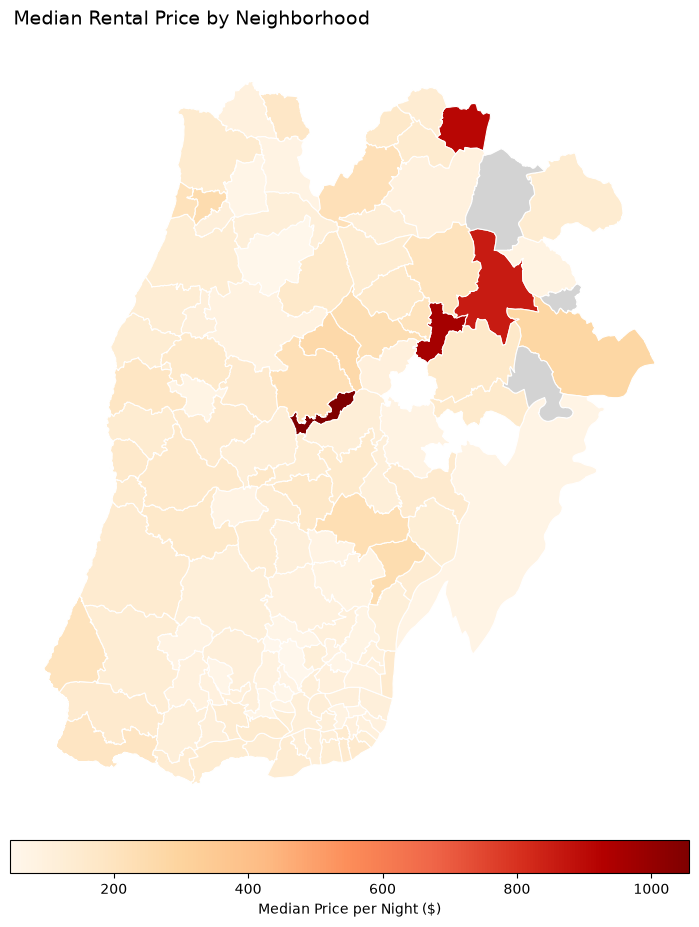

In [9]:
import matplotlib.pyplot as plt
import geopandas as gpd


merged = boundaries.merge(
    neighborhood_stats, left_on='neighbourhood', right_index=True
)



fig, ax = plt.subplots(figsize=(10, 10))
ax.set_axis_off()  

merged.plot(
    ax=ax,
    column='median_price', 
    cmap='OrRd', 
    legend=True,
    edgecolor='white',       
    linewidth=0.8,           
    missing_kwds={           
        "color": "lightgrey", 
        "label": "No Data"
    },
    legend_kwds={
        'label': "Median Price per Night ($)",
        'orientation': "horizontal", 
        'shrink': 0.7,             
        'pad': 0.02                
    }
)

# 4. Clear structural hierarchy
ax.set_title("Median Rental Price by Neighborhood", fontsize=14, pad=15, loc='left')

plt.tight_layout()
plt.show()
